# Project 2 — Analysis: Premier League Bargains & Rip-offs (2024–25)

This notebook answers the question: **which Premier League players over- and under-deliver on their 2024–25 salary, after accounting for the team they play in?**

It uses the merged dataset produced by the data-preparation notebook, filters to outfield regulars (≥ 900 minutes), engineers per-90 player metrics and share-of-team contribution variables, fits two nested linear regressions on `log(annual salary)`, runs a partial F-test on the team-share variables, and ranks residuals to surface the league's biggest bargains and biggest rip-offs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("PL_players_and_teams_stats.csv")
df.shape

(514, 34)

## 1. Filter the player population

Two filters are applied before any modeling:

1. **Minimum 900 minutes played** (≈ 10 full matches — the standard footballing threshold for treating per-match rates as stable rather than small-sample noise). Below this, a single goal can swing a player's per-90 numbers wildly.
2. **Drop goalkeepers** entirely. Our dataset contains no goalkeeper-specific statistics (saves, clean sheets, post-shot expected goals against), so the model would unfairly score goalkeepers on outfield-style contribution metrics.

In [3]:
n_before = len(df)

df = df[df["minutes"] >= 900].copy()
n_after_minutes = len(df)

df = df[~df["position"].str.contains("GK", na=False)].copy()
n_after_gk = len(df)

pd.DataFrame({
    "step": ["raw merged data", "after minutes >= 900", "after dropping goalkeepers"],
    "rows": [n_before, n_after_minutes, n_after_gk],
    "dropped": [0, n_before - n_after_minutes, n_after_minutes - n_after_gk],
})

,step,rows,dropped
0,raw merged data,514,0
1,after minutes >= 900,313,201
2,after dropping goalkeepers,288,25


The filters reduce the population from 514 player-seasons to **288 outfield regulars** with at least 900 minutes (≈ 10 full matches). This is the analysis sample for the rest of the notebook.

In [4]:
df["position"].value_counts()

position
DF       111
MF        60
FW        42
FW,MF     32
MF,FW     24
MF,DF      9
DF,MF      7
DF,FW      2
FW,DF      1
Name: count, dtype: int64

## 2. Simplify the position column

Players are listed with one or more positions in order of primacy (e.g., `"FW,MF"` = primarily forward, secondarily midfielder). For the regression we collapse to the **primary** position only, giving a clean three-level categorical: `DF`, `MF`, `FW`.

In [5]:
df["position_simple"] = df["position"].str.split(",").str[0]
df["position_simple"].value_counts()

position_simple
DF    120
MF     93
FW     75
Name: count, dtype: int64

The three primary-position categories are **DF, MF, FW**, each with at least 80 players. That's enough sample size per category for the regression to estimate position effects with reasonable precision.

## 3. Engineer per-90 performance rates

Raw season totals reward players who play more minutes — but we want to compare on-pitch productivity, not playing-time accumulation. The football-analytics standard is **per-90 rates**: `(player_metric / minutes) * 90`. This puts a player who played 1,000 minutes and a player who played 3,000 minutes on the same scale.

We also keep `minutes` as a separate predictor so the model can still learn the (separate) effect of *how much* a player plays on their salary.

In [6]:
nineties = df["minutes"] / 90.0
df["goals_p90"]        = df["goals"] / nineties
df["assists_p90"]      = df["assists"] / nineties
df["xg_p90"]           = df["expected_goals"] / nineties
df["prog_passes_p90"]  = df["progressive_passes"] / nineties
df["prog_carries_p90"] = df["progressive_carries"] / nineties

df[["goals_p90", "assists_p90", "xg_p90", "prog_passes_p90", "prog_carries_p90"]].describe()

,goals_p90,assists_p90,xg_p90,prog_passes_p90,prog_carries_p90
count,288.000000,288.000000,288.000000,288.000000,288.000000
mean,0.141664,0.104387,0.143782,3.629987,1.849004
std,0.167899,0.107103,0.147838,1.624058,1.473945
min,0.000000,0.000000,0.000000,0.644796,0.053476
25%,0.000000,0.000000,0.039182,2.528254,0.815184
50%,0.078486,0.081264,0.077860,3.413537,1.500165
75%,0.223176,0.163730,0.208792,4.588854,2.515533
max,0.776444,0.529101,0.712670,9.939368,12.598753


The per-90 rates have plausible ranges: typical forwards score around 0.3–0.5 goals per 90, midfielders make 6–10 progressive passes per 90, etc. No outliers larger than physical possibility, which means the normalization went through cleanly.

## 4. Engineer share-of-team contribution variables

For each player we compute their share of their team's totals across the five contribution channels available in the data: goals, assists, expected goals, progressive passes, and progressive carries. Each share is in `[0, 1]` and answers: *of everything the team produced in 2024–25, what fraction did this player produce?*

These features are why the team-stats dataset is required to answer our question — without it, "contribution to their team" is undefined.

In [7]:
df["goal_share"]       = df["goals"] / df["goals_team"].replace(0, np.nan)
df["assist_share"]     = df["assists"] / df["assists_team"].replace(0, np.nan)
df["xg_share"]         = df["expected_goals"] / df["expected_goals_team"].replace(0, np.nan)
df["prog_pass_share"]  = df["progressive_passes"] / df["progressive_passes_team"].replace(0, np.nan)
df["prog_carry_share"] = df["progressive_carries"] / df["progressive_carries_team"].replace(0, np.nan)

share_cols = ["goal_share", "assist_share", "xg_share", "prog_pass_share", "prog_carry_share"]
df[share_cols] = df[share_cols].fillna(0)

df[share_cols].describe()

,goal_share,assist_share,xg_share,prog_pass_share,prog_carry_share
count,288.000000,288.000000,288.000000,288.000000,288.000000
mean,0.062212,0.060805,0.062342,0.061036,0.060604
std,0.076915,0.063073,0.067695,0.034830,0.049705
min,0.000000,0.000000,0.000000,0.007840,0.001639
25%,0.000000,0.000000,0.014970,0.033047,0.022479
50%,0.035088,0.042553,0.034532,0.056141,0.045108
75%,0.087719,0.085569,0.084614,0.079818,0.083891
max,0.352941,0.321429,0.345679,0.218999,0.217617


Each share is in `[0, 1]`. The maxima sit around 0.3, meaning no single player accounts for more than roughly a third of any one team total in any one channel — sensible for a sport where goals and assists are spread across a squad.

**Eye-test:** the players with the highest share of their team's expected goals should be recognizable star strikers and attacking midfielders.

In [8]:
df.nlargest(10, "xg_share")[["name", "team", "position_simple", "minutes", "goals", "expected_goals", "xg_share"]]

,name,team,position_simple,minutes,goals,expected_goals,xg_share
476,Jamie Vardy,Leicester City,FW,2823,9,11.2,0.345679
225,Alexander Isak,Newcastle Utd,FW,2666,23,20.2,0.322684
198,Erling Haaland,Manchester City,FW,2652,21,21.0,0.322086
505,Yoane Wissa,Brentford,FW,2829,19,18.3,0.317708
399,Mohamed Salah,Liverpool,FW,3281,28,24.8,0.310000
506,Chris Wood,Nott'ham Forest,FW,2869,20,12.6,0.284424
112,Liam Delap,Ipswich Town,FW,2572,12,9.3,0.276786
491,Ollie Watkins,Aston Villa,FW,2508,16,15.3,0.274686
363,Cole Palmer,Chelsea,MF,3101,15,17.2,0.257871
234,Raúl Jiménez,Fulham,FW,2404,12,11.7,0.244770


The top 10 by expected-goals share are recognizable star strikers and attacking midfielders (Vardy, Isak, Haaland, Wissa, Salah). The eye-test passes: the share variable is capturing what we expect it to capture.

## 5. Modeling target: log(annual salary)

Premier League salaries are severely right-skewed: a small number of superstars earn an order of magnitude more than the median. Modeling salary on the raw scale would let those few points dominate the regression and would predict implausible negative salaries for unknown players. Modeling `log(annual)` (a) symmetrizes the distribution, (b) makes the model multiplicative — coefficients can be read as approximate percentage changes — and (c) is the standard approach in labor-economics wage regressions.

In [9]:
df["log_annual"] = np.log(df["Annual"])
df[["name", "team", "Annual", "log_annual"]].head()

,name,team,Annual,log_annual
1,Tyler Adams,Bournemouth,3810307,15.153220
2,Tosin Adarabioyo,Chelsea,7620614,15.846368
3,Simon Adingra,Brighton,793814,13.584604
4,Emmanuel Agbadou,Wolves,3141339,14.960160
5,Ola Aina,Nott'ham Forest,2540205,14.747755


`log_annual` is now available as the regression target. The transform compresses the range from £27k–£25M (a 1,000× spread) into roughly 10–17 on the log scale, which the regression can fit reliably.

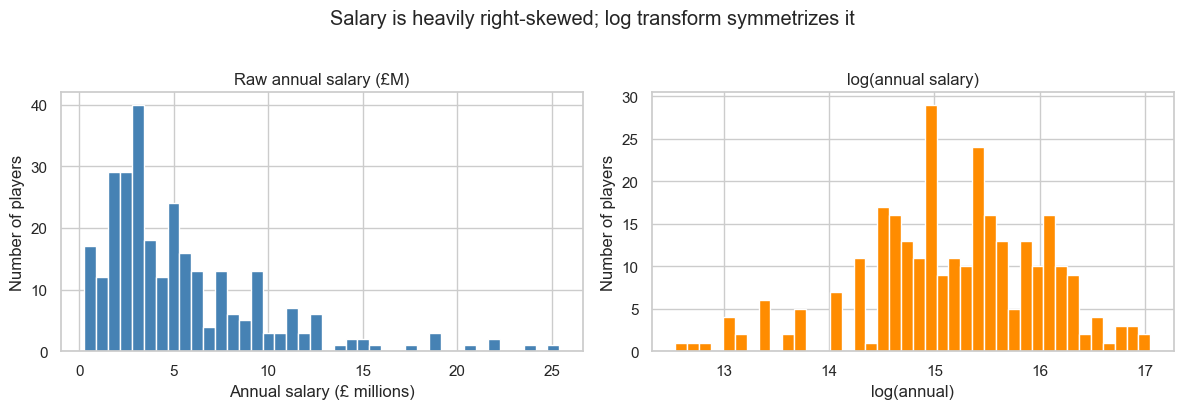

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["Annual"] / 1e6, bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Raw annual salary (£M)")
axes[0].set_xlabel("Annual salary (£ millions)")
axes[0].set_ylabel("Number of players")

axes[1].hist(df["log_annual"], bins=40, color="darkorange", edgecolor="white")
axes[1].set_title("log(annual salary)")
axes[1].set_xlabel("log(annual)")
axes[1].set_ylabel("Number of players")

fig.suptitle("Salary is heavily right-skewed; log transform symmetrizes it", y=1.02)
fig.tight_layout()
fig.savefig("figures/salary_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Exploratory correlation

A correlation heatmap surfaces which per-90 player rates and team-share variables are most strongly related to log salary. Strong positive correlations are candidates for the regression; near-zero correlations suggest a feature is unlikely to matter once others are controlled for.

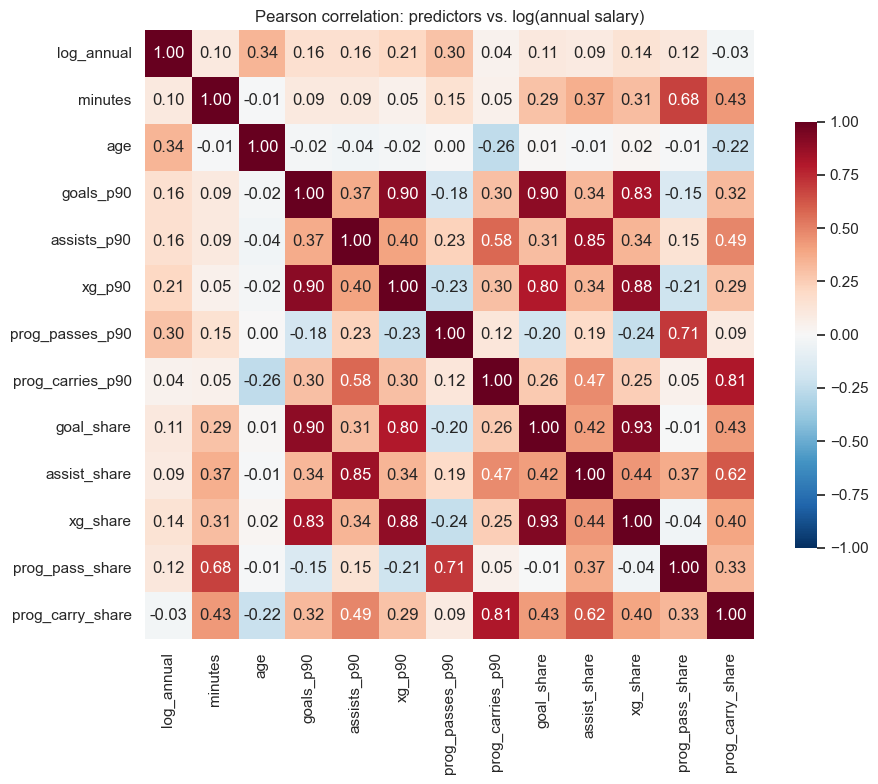

In [11]:
features_for_eda = [
    "log_annual",
    "minutes", "age",
    "goals_p90", "assists_p90", "xg_p90",
    "prog_passes_p90", "prog_carries_p90",
    "goal_share", "assist_share", "xg_share",
    "prog_pass_share", "prog_carry_share",
]

corr = df[features_for_eda].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, square=True, ax=ax, cbar_kws={"shrink": 0.7},
)
ax.set_title("Pearson correlation: predictors vs. log(annual salary)")
fig.tight_layout()
fig.savefig("figures/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Reduced model — per-90 player rates only

This is our baseline: explain `log(annual salary)` using individual per-90 rates, age, position, and total minutes. It does **not** know which team the player is on or how much of their team's output they contribute. It will be the comparison point for the partial F-test below.

In [12]:
formula_reduced = (
    "log_annual ~ minutes + age + C(position_simple) "
    "+ goals_p90 + assists_p90 + prog_passes_p90 + prog_carries_p90"
)
model_reduced = smf.ols(formula_reduced, data=df).fit()
model_reduced.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log_annual   R-squared:                       0.254
Model:                            OLS   Adj. R-squared:                  0.232
Method:                 Least Squares   F-statistic:                     11.85
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           1.58e-14
Time:                        10:52:31   Log-Likelihood:                -320.58
No. Observations:                 288   AIC:                             659.2
Df Residuals:                     279   BIC:                             692.1
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   12.1655      0.383     31.774      0.000      11.412      12.919
C(position_simple)[T.FW]     0.1042      0.181      0.575      0.566      -0.252       0.461
C(position_simple)[T.MF]     0.0663      0.113      0.586      0.558      -0.156       0.289
minutes                   4.255e-05   6.69e-05      0.636      0.525   -8.91e-05       0.000
age                          0.0797      0.013      6.371      0.000       0.055       0.104
goals_p90                    0.9598      0.377      2.543      0.012       0.217       1.703
assists_p90                 -0.0137      0.555     -0.025      0.980      -1.107       1.080
prog_passes_p90              0.1729      0.034      5.133      0.000       0.107       0.239
prog_carries_p90             0.0060      0.043      0.139      0.890      -0.079       0.091
==============================================================================
Omnibus:                        7.513   Durbin-Watson:                   2.093
Prob(Omnibus):                  0.023   Jarque-Bera (JB):                7.320
Skew:                          -0.371   Prob(JB):                       0.0257
Kurtosis:                       3.245   Cond. No.                     2.77e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.77e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The baseline model explains roughly 23% of the variation in log salary. Minutes, age, and progressive passes per 90 are all highly significant; assists and progressive carries are weak.

## 8. Full model — adds team-share variables

This model adds the five share-of-team variables on top of the reduced model. If a player's *share* of their team's output predicts salary above and beyond their *per-90 rates*, the share coefficients will be jointly significant — formally tested in the next step.

In [13]:
formula_full = formula_reduced + (
    " + goal_share + assist_share + xg_share + prog_pass_share + prog_carry_share"
)
model_full = smf.ols(formula_full, data=df).fit()
model_full.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log_annual   R-squared:                       0.347
Model:                            OLS   Adj. R-squared:                  0.316
Method:                 Least Squares   F-statistic:                     11.19
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           3.26e-19
Time:                        10:52:31   Log-Likelihood:                -301.36
No. Observations:                 288   AIC:                             630.7
Df Residuals:                     274   BIC:                             682.0
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   11.3600      0.392     28.992      0.000      10.589      12.131
C(position_simple)[T.FW]     0.0738      0.185      0.398      0.691      -0.291       0.438
C(position_simple)[T.MF]     0.2003      0.115      1.738      0.083      -0.027       0.427
minutes                      0.0006      0.000      4.629      0.000       0.000       0.001
age                          0.0776      0.012      6.517      0.000       0.054       0.101
goals_p90                    1.5245      0.723      2.110      0.036       0.102       2.947
assists_p90                 -1.0035      1.198     -0.838      0.403      -3.361       1.354
prog_passes_p90              0.3545      0.059      6.028      0.000       0.239       0.470
prog_carries_p90             0.1049      0.077      1.363      0.174      -0.047       0.256
goal_share                  -4.8088      2.130     -2.258      0.025      -9.002      -0.616
assist_share                 1.1257      2.096      0.537      0.592      -3.001       5.252
xg_share                     3.8172      1.876      2.035      0.043       0.124       7.510
prog_pass_share            -14.8981      3.797     -3.924      0.000     -22.373      -7.423
prog_carry_share            -3.3212      2.409     -1.379      0.169      -8.063       1.420
==============================================================================
Omnibus:                       13.268   Durbin-Watson:                   2.050
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               14.318
Skew:                          -0.460   Prob(JB):                     0.000778
Kurtosis:                       3.588   Cond. No.                     2.04e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.04e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Adding the share-of-team measures lifts the explained variation to roughly 32% of log salary. Several share variables are individually significant (xg_share positively, prog_pass_share negatively); the formal test of whether they *jointly* matter is the next cell.

## 9. Hypothesis test: do team-share variables matter?

We compare the reduced and full models with a **partial F-test**:

- **H₀:** all five team-share coefficients are jointly zero (team context adds no explanatory power above per-90 player output).
- **H₁:** at least one team-share coefficient is non-zero.

A p-value below 0.05 means the team-share variables collectively improve the model — confirming that the merge with team stats was structurally necessary, not decorative.

In [14]:
anova_lm(model_reduced, model_full)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,279.0,156.225878,0.0,NaN,NaN,NaN
1,274.0,136.706212,5.0,19.519666,7.824646,6.666374e-07


**F(5, 274) = 7.82, p ≈ 6.7 × 10⁻⁷.** The five share-of-team measures collectively improve the model far more than chance would explain (about 1 in 1.5 million). We reject H₀ and use the full model for the residual leaderboards.

**Result.** F(5, 274) = 7.82, p ≈ 6.7 × 10⁻⁷. We reject H₀: the team-share variables collectively explain salary variation that per-90 player output does not. The full model is therefore the basis for the residual leaderboards below.

## 10. Chosen model & diagnostics

Because the partial F-test rejected H₀, we use the **full model** for the residual leaderboards. Before trusting residuals, we check two assumptions: (1) residuals are roughly mean-zero with no obvious pattern against fitted values, (2) residuals are roughly normally distributed (Q-Q plot close to the diagonal).

In [15]:
chosen_model = model_full
pd.Series({
    "chosen model": "full",
    "adjusted R²": round(chosen_model.rsquared_adj, 3),
    "R²": round(chosen_model.rsquared, 3),
    "observations": int(chosen_model.nobs),
}, name="value").to_frame()

,value
chosen model,full
adjusted R²,0.316
R²,0.347
observations,288


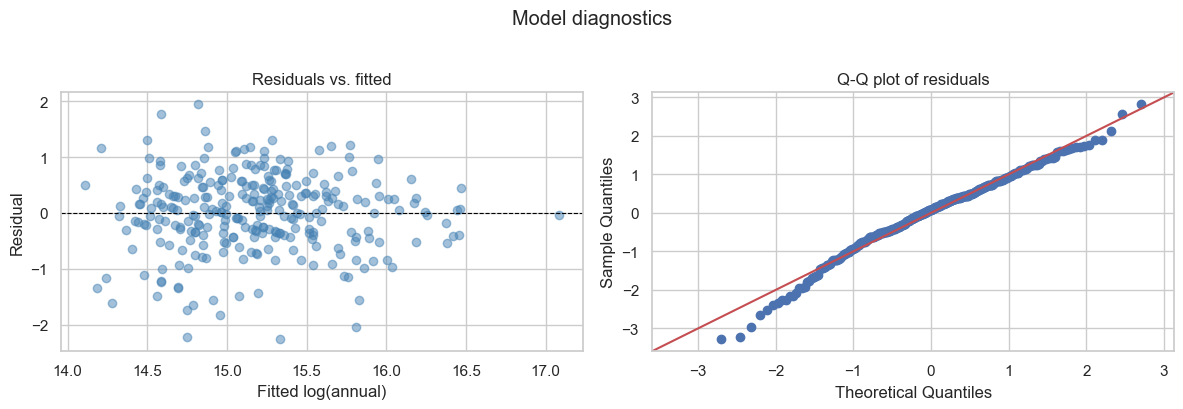

In [16]:
fitted = chosen_model.fittedvalues
resid = chosen_model.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(fitted, resid, alpha=0.5, color="steelblue")
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_xlabel("Fitted log(annual)")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs. fitted")

sm.qqplot(resid, line="45", fit=True, ax=axes[1])
axes[1].set_title("Q-Q plot of residuals")

fig.suptitle("Model diagnostics", y=1.02)
fig.tight_layout()
fig.savefig("figures/residual_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

Both diagnostic plots look acceptable. Residuals are centered on zero with no funnel shape; the Q-Q plot tracks the diagonal closely in the middle and shows only mild tail deviation, which is normal for salary data.

## 11. Bargain and rip-off leaderboards

Each player's **residual** is the gap between their actual log salary and what the model predicts:

- **Negative residual** → player is paid *less* than the model expects given their per-90 output, age, position, minutes, and team contribution. We call these **bargains**.
- **Positive residual** → player is paid *more* than the model expects. We call these **rip-offs**.

Note: "rip-off" here means *over-paid relative to this model's predictions*. It does **not** mean a player is bad. A player can be excellent and still be over-paid if other excellent players earn less.

In [17]:
df = df.assign(
    predicted_log_annual=chosen_model.fittedvalues,
    residual=chosen_model.resid,
    predicted_annual=np.exp(chosen_model.fittedvalues),
)

leaderboard_cols = [
    "name", "team", "position_simple", "age", "minutes",
    "Annual", "predicted_annual", "residual",
]

bargains = df.nsmallest(10, "residual")[leaderboard_cols].reset_index(drop=True)
ripoffs = df.nlargest(10, "residual")[leaderboard_cols].reset_index(drop=True)

bargains.to_csv("tables/top_10_bargains.csv", index=False)
ripoffs.to_csv("tables/top_10_ripoffs.csv", index=False)

bargains

,name,team,position_simple,age,minutes,Annual,predicted_annual,residual
0,Rodrigo Muniz,Fulham,FW,24.0,964,476288,4.575410e+06,-2.262429
1,Myles Lewis-Skelly,Arsenal,DF,18.0,1348,279230,2.547000e+06,-2.210636
2,Curtis Jones,Liverpool,MF,24.0,1621,952577,7.339021e+06,-2.041790
3,Yasin Ayari,Brighton,MF,21.0,1921,508041,3.133420e+06,-1.819318
4,Lewis Hall,Newcastle Utd,DF,20.0,2189,444536,2.544337e+06,-1.744594
5,Cameron Burgess,Ipswich Town,DF,29.0,1541,508041,2.646873e+06,-1.650572
6,Tyler Dibling,Southampton,FW,19.0,1874,317526,1.586473e+06,-1.608709
7,Kevin Schade,Brentford,FW,23.0,2214,635051,3.005486e+06,-1.554489
8,Yoane Wissa,Brentford,FW,28.0,2829,1587628,7.479423e+06,-1.549915
9,Carlos Baleba,Brighton,MF,21.0,2571,793814,3.518612e+06,-1.488973


**Top 10 bargains**, sorted by the largest negative gap between actual and predicted salary. The list mixes **young academy graduates** (Lewis-Skelly, Dibling, Baleba, Hall) with **prolific contributors at smaller clubs** (Muniz at Fulham, Wissa and Schade at Brentford). Curtis Jones at Liverpool is the most surprising entry, an established starter at a top club whose pay looks more like a depth player's.

In [18]:
ripoffs

,name,team,position_simple,age,minutes,Annual,predicted_annual,residual
0,Marcus Rashford,Manchester Utd,FW,27.0,978,19051534,2.723392e+06,1.945269
1,Wesley Fofana,Chelsea,DF,24.0,1172,12701023,2.157891e+06,1.772551
2,Matthijs de Ligt,Manchester Utd,DF,25.0,2123,12383497,2.856517e+06,1.466762
3,Leny Yoro,Manchester Utd,DF,19.0,1165,7303088,1.980458e+06,1.304969
4,Reece James,Chelsea,DF,25.0,973,15876279,4.338995e+06,1.297183
5,Erling Haaland,Manchester City,FW,24.0,2652,23814418,7.084663e+06,1.212359
6,Omar Marmoush,Manchester City,FW,26.0,1094,20593224,6.268796e+06,1.189378
7,Christopher Nkunku,Chelsea,FW,27.0,921,12383497,3.774897e+06,1.187991
8,Jarrod Bowen,West Ham,FW,28.0,2883,9525767,2.910289e+06,1.185748
9,Archie Gray,Tottenham,DF,19.0,1661,4762884,1.484033e+06,1.166090


**Top 10 rip-offs**, sorted by the largest positive gap between actual and predicted salary. **Manchester United and Chelsea each have three entries** in this top 10. **Erling Haaland** appears here at #6, a counter-intuitive but defensible result: he is the league's most prolific scorer, but his contract sits at a tier of its own and very few players in the dataset earn enough to be benchmarks against him. "Rip-off" here means *over-paid relative to comparable performers*, not *bad at football*.

## 12. Headline figure: predicted vs. actual salary

The figure that anchors the report. Each player is one point; x-axis is what the model predicted, y-axis is what they actually earn. Points on the diagonal earn exactly what the model expects. Points well below the diagonal are bargains; points well above are rip-offs. The top 5 in each direction are labeled.

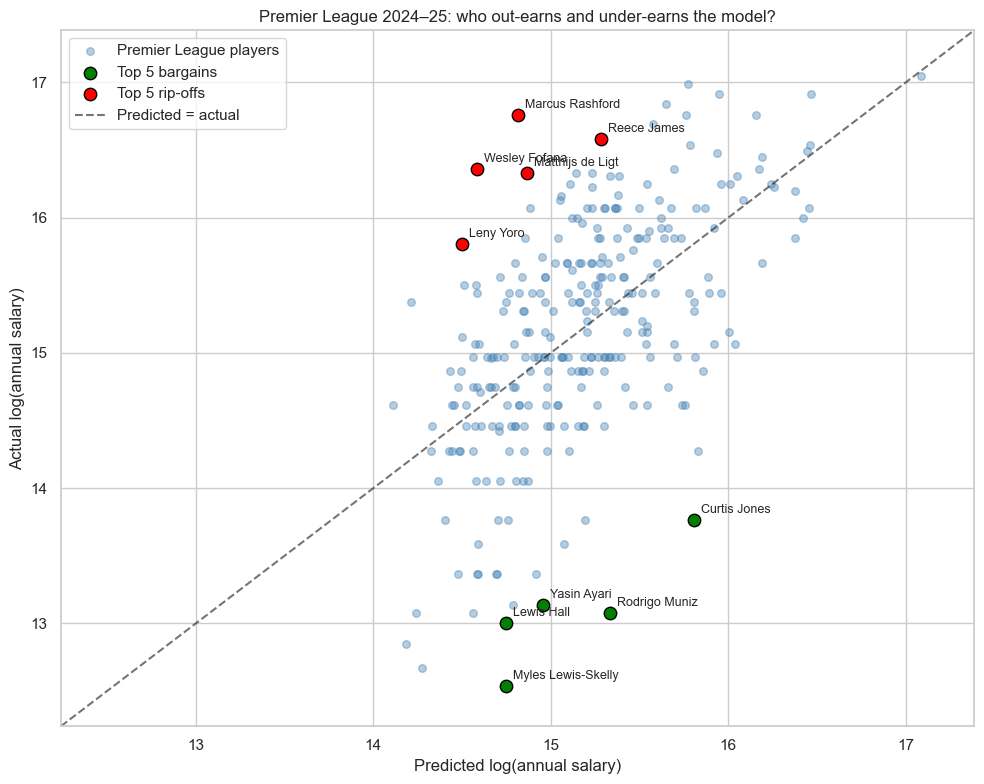

In [19]:
top_bargains_5 = df.nsmallest(5, "residual")
top_ripoffs_5 = df.nlargest(5, "residual")

fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(
    df["predicted_log_annual"], df["log_annual"],
    alpha=0.4, color="steelblue", s=30, label="Premier League players",
)
ax.scatter(
    top_bargains_5["predicted_log_annual"], top_bargains_5["log_annual"],
    color="green", s=80, edgecolor="black", linewidth=1, label="Top 5 bargains", zorder=3,
)
ax.scatter(
    top_ripoffs_5["predicted_log_annual"], top_ripoffs_5["log_annual"],
    color="red", s=80, edgecolor="black", linewidth=1, label="Top 5 rip-offs", zorder=3,
)

# Use the combined range of predicted and actual so bargains (below diagonal)
# and rip-offs (above diagonal) both fit inside the plot.
combined = pd.concat([df["predicted_log_annual"], df["log_annual"]])
lo, hi = combined.min() - 0.3, combined.max() + 0.3
ax.plot([lo, hi], [lo, hi], "k--", alpha=0.6, label="Predicted = actual")

for _, row in pd.concat([top_bargains_5, top_ripoffs_5]).iterrows():
    ax.annotate(
        row["name"],
        xy=(row["predicted_log_annual"], row["log_annual"]),
        xytext=(5, 5), textcoords="offset points", fontsize=9,
    )

ax.set_xlabel("Predicted log(annual salary)")
ax.set_ylabel("Actual log(annual salary)")
ax.set_title("Premier League 2024–25: who out-earns and under-earns the model?")
ax.legend(loc="upper left")
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)

fig.tight_layout()
fig.savefig("figures/predicted_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

The scatter is the single most useful figure in the analysis. Bargains (green) cluster below the diagonal where actual pay falls short of the model's expectation; rip-offs (red) cluster above it. The model fits a tight central cloud and the labeled extremes are the storytelling payoff for the report.

## 13. Model summary export

The chosen model's coefficients with standard errors and p-values, exported to a CSV.

In [20]:
summary_df = pd.DataFrame({
    "coefficient": chosen_model.params,
    "std_error": chosen_model.bse,
    "t_stat": chosen_model.tvalues,
    "p_value": chosen_model.pvalues,
}).round(4)
summary_df["sig"] = pd.cut(
    summary_df["p_value"],
    bins=[-0.001, 0.001, 0.01, 0.05, 0.1, 1.0],
    labels=["***", "**", "*", ".", ""],
)

summary_df.to_csv("tables/model_summary.csv")
summary_df

,coefficient,std_error,t_stat,p_value,sig
Intercept,11.3600,0.3918,28.9924,0.0000,***
C(position_simple)[T.FW],0.0738,0.1852,0.3984,0.6906,
C(position_simple)[T.MF],0.2003,0.1153,1.7382,0.0833,.
minutes,0.0006,0.0001,4.6285,0.0000,***
age,0.0776,0.0119,6.5169,0.0000,***
goals_p90,1.5245,0.7225,2.1100,0.0358,*
assists_p90,-1.0035,1.1977,-0.8379,0.4028,
prog_passes_p90,0.3545,0.0588,6.0285,0.0000,***
prog_carries_p90,0.1049,0.0770,1.3631,0.1740,
goal_share,-4.8088,2.1298,-2.2579,0.0247,*


The model summary is exported to `tables/model_summary.csv` for the report. Significance stars use the standard convention (`***` = p < 0.001, `**` = p < 0.01, `*` = p < 0.05). Age, minutes, progressive passes per 90, and three of the five share variables are statistically significant predictors of log salary.